In [6]:
import pandas as pd

happiness = pd.read_csv("happiness.csv")
happiness.head()

,Country,Score,GDP per capita
0,Bulgaria,5.1,1.2
1,Germany,6.8,2.5
2,France,6.7,2.3
3,USA,7.0,3.0
4,Japan,6.1,2.2


In [7]:
development = pd.read_csv("development.csv")

development.head()

,Country,Life Expectancy
0,Bulgaria,75
1,Germany,81
2,France,82
3,USA,79
4,Japan,84


In [8]:
data = pd.merge(happiness, development, on="Country")

data.head()

,Country,Score,GDP per capita,Life Expectancy
0,Bulgaria,5.1,1.2,75
1,Germany,6.8,2.5,81
2,France,6.7,2.3,82
3,USA,7.0,3.0,79
4,Japan,6.1,2.2,84


In [9]:
data = data.dropna()
data

,Country,Score,GDP per capita,Life Expectancy
0,Bulgaria,5.1,1.2,75
1,Germany,6.8,2.5,81
2,France,6.7,2.3,82
3,USA,7.0,3.0,79
4,Japan,6.1,2.2,84
5,India,4.0,0.9,70
6,Brazil,6.3,1.8,75
7,Canada,7.2,3.1,83
8,Australia,7.3,3.2,84
9,Italy,6.5,2.0,83


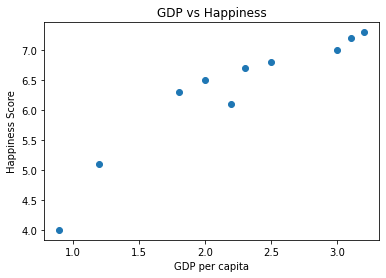

In [10]:
import matplotlib.pyplot as plt

plt.scatter(data["GDP per capita"], data["Score"])
plt.xlabel("GDP per capita")
plt.ylabel("Happiness Score")
plt.title("GDP vs Happiness")
plt.show()

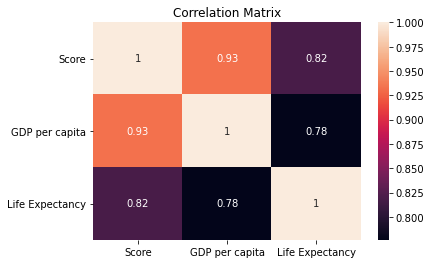

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

## Pearson Correlation

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \cdot \sum (y_i - \bar{y})^2}}
$$

In [23]:
print(data.columns)

Index(['Country', 'Score', 'GDP per capita', 'Life Expectancy'], dtype='object')


In [26]:
from sklearn.linear_model import LinearRegression

X = data[["GDP per capita"]]
y = data["Score"]

model = LinearRegression()
model.fit(X, y)

data["Predicted"] = model.predict(X)
data.head()

,Country,Score,GDP per capita,Life Expectancy,Predicted
0,Bulgaria,5.1,1.2,75,5.040949
1,Germany,6.8,2.5,81,6.645622
2,France,6.7,2.3,82,6.398749
3,USA,7.0,3.0,79,7.262804
4,Japan,6.1,2.2,84,6.275313


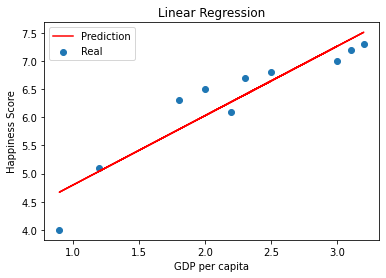

In [27]:
plt.scatter(data["GDP per capita"], data["Score"], label="Real")
plt.plot(data["GDP per capita"], data["Predicted"], color="red", label="Prediction")

plt.xlabel("GDP per capita")
plt.ylabel("Happiness Score")
plt.title("Linear Regression")
plt.legend()
plt.show()

## Conclusion

The analysis shows a positive relationship between GDP per capita and happiness.

However, happiness depends on multiple factors beyond GDP.